# Credit Card Customer Experience & Complaint Analysis
### Project: Hypothesis-driven CX analysis on CFPB credit card complaints (structured + NLP)

**Objective:** Identify drivers of customer dissatisfaction in credit card servicing using structured complaint metadata and free-text narratives (NLP + GenAI summarization).

**Data source:** CFPB Consumer Complaint Database — filtered to Credit card/prepaid card, complaints with narratives.

## 1. Import Libraries

In [1]:
# Core libraries for data handling
import pandas as pd
import numpy as np

# Display settings so we can see full narrative text when needed
pd.set_option('display.max_colwidth', 200)

## 2. Load Raw Data
Loading the full exported CFPB CSV. This file is large (~1.3GB), so this step may take a minute.

In [4]:
# Read the large file in chunks to avoid memory errors.
# We only keep the columns we actually need, and drop rows without a narrative,
# right inside the loop — so memory never holds the full 1.3GB file at once.

cols_needed = ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
               'Consumer complaint narrative', 'Company', 'State',
               'Company response to consumer', 'Timely response?']

chunks = []
chunk_size = 50000  # rows per chunk

for chunk in pd.read_csv('complaints.csv', usecols=cols_needed,
                          chunksize=chunk_size, low_memory=False):
    # Keep only rows that actually have a narrative
    chunk = chunk.dropna(subset=['Consumer complaint narrative'])
    chunks.append(chunk)

# Combine all filtered chunks into one dataframe
df = pd.concat(chunks, ignore_index=True)

print(df.shape)
print(df.columns.tolist())

(3844964, 10)
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company', 'State', 'Company response to consumer', 'Timely response?']


In [5]:
# Filter to only credit card / prepaid card complaints
df = df[df['Product'] == 'Credit card or prepaid card']

print(df.shape)
print(df['Product'].unique())

(108683, 10)
<StringArray>
['Credit card or prepaid card']
Length: 1, dtype: str


## 3. Filter to Recent Date Range
Narrowing to a recent window keeps the analysis relevant to current CX issues and reduces file size for processing.

In [6]:
# Convert date column to datetime type
df['Date received'] = pd.to_datetime(df['Date received'])

# Keep only the last 3 years of complaints
df = df[df['Date received'] >= '2023-01-01']

print(df.shape)
print(df['Date received'].min(), '-', df['Date received'].max())

(21283, 10)
2023-01-01 00:00:00 - 2023-08-25 00:00:00


In [7]:
# Sanity check: what's the actual date range in the full downloaded file
# (before we filtered to 2023-01-01 onward)?
print(df['Date received'].max())

2023-08-25 00:00:00


In [8]:
# Reset index after filtering
df = df.reset_index(drop=True)

# Quick look at the data
df.head(3)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company,State,Company response to consumer,Timely response?
0,2023-03-11,Credit card or prepaid card,General-purpose credit card or charge card,Getting a credit card,Sent card you never applied for,"SNYCB / Paypal credit card They opened a credit card account in my name WITHOUT an application from me! between XX/XX/2023 and XX/XX/2023, this card was added to my credit report I made NO request...",SYNCHRONY FINANCIAL,NV,Closed with non-monetary relief,Yes
1,2023-03-11,Credit card or prepaid card,General-purpose credit card or charge card,Problem when making payments,You never received your bill or did not know a payment was due,I had a business credit card with bank of America. Began a repayment plan. The attached email shows the agreement. It says I can pay online. Once started they closed my account. They send me email...,"BANK OF AMERICA, NATIONAL ASSOCIATION",CA,Closed with explanation,No
2,2023-03-11,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Card was charged for something you did not purchase with the card,I called Discover to report my card lost. I told a representative from Discover to review a summary of charges before they send me new one. After reviewing an unauthorized charge for {$4200.00} wa...,DISCOVER BANK,NY,Closed with explanation,Yes


## 4. Clean Narrative Text
CFPB narratives contain redaction placeholders (e.g. "XX/XX/2023", "XXXX") for privacy.
We remove these before NLP so they don't appear as noise in topic modeling.

In [9]:
import re

def clean_narrative(text):
    # Remove CFPB's redaction placeholders (dates, names, etc. shown as XX/XX or XXXX)
    text = re.sub(r'X{2,}', '', text)
    text = re.sub(r'\d{2}/\d{2}/\d{4}', '', text)
    
    # Collapse extra whitespace left behind after removals
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df['narrative_clean'] = df['Consumer complaint narrative'].apply(clean_narrative)

# Compare original vs cleaned for one row
print("ORIGINAL:\n", df['Consumer complaint narrative'].iloc[0])
print("\nCLEANED:\n", df['narrative_clean'].iloc[0])

ORIGINAL:
 SNYCB / Paypal credit card They opened a credit card account in my name WITHOUT an application from me! between XX/XX/2023 and XX/XX/2023, this card was added to my credit report I made NO request for this account NOR did I file an application for this account. 
I do not want this account! 


Calling them to get this problem rectified is also Problem as you are on Hold for ever! 
All the guy on phone does is apologize, and refuses to explain how or why the application was made on their part. 

This has resulted in a Hard inquiry on my credit and a reduction of my credit line. 

They are not willing to say what happened or why and also claim it will not affect my Paypal account. BUT I do not believe them. I have had my Pay pal account for years and never had a Problem BUT at this point I may be closing my account.

CLEANED:
 SNYCB / Paypal credit card They opened a credit card account in my name WITHOUT an application from me! between //2023 and //2023, this card was added to

In [10]:
import re

def clean_narrative(text):
    # Remove redacted dates first (before removing the X's breaks the pattern)
    text = re.sub(r'XX/XX/\d{4}', '', text)
    
    # Remove any remaining XXXX-style placeholders (redacted names, account numbers, etc.)
    text = re.sub(r'X{2,}', '', text)
    
    # Collapse extra whitespace left behind after removals
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df['narrative_clean'] = df['Consumer complaint narrative'].apply(clean_narrative)

# Compare original vs cleaned for one row
print("ORIGINAL:\n", df['Consumer complaint narrative'].iloc[0])
print("\nCLEANED:\n", df['narrative_clean'].iloc[0])

ORIGINAL:
 SNYCB / Paypal credit card They opened a credit card account in my name WITHOUT an application from me! between XX/XX/2023 and XX/XX/2023, this card was added to my credit report I made NO request for this account NOR did I file an application for this account. 
I do not want this account! 


Calling them to get this problem rectified is also Problem as you are on Hold for ever! 
All the guy on phone does is apologize, and refuses to explain how or why the application was made on their part. 

This has resulted in a Hard inquiry on my credit and a reduction of my credit line. 

They are not willing to say what happened or why and also claim it will not affect my Paypal account. BUT I do not believe them. I have had my Pay pal account for years and never had a Problem BUT at this point I may be closing my account.

CLEANED:
 SNYCB / Paypal credit card They opened a credit card account in my name WITHOUT an application from me! between and , this card was added to my credit re

## 5. Sentiment Scoring
Using TextBlob to score each narrative's sentiment polarity (-1 = very negative, +1 = very positive).
This gives a quick, explainable way to quantify dissatisfaction per complaint — a lexicon-based
score, not a trained model, so it's simple to justify: each word in the text has a known polarity
score, and TextBlob averages them across the narrative.

!pip install textblob

In [13]:
pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 13.5 MB/s  0:00:00
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 10.1 MB/s  0:00:00

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ------ --------------------------------- 1/6 [regex]
   ------ --------------------------------- 1/6 [regex]
   ------ --------------------------------- 1/6 [regex]
   ------------- -------------------------- 2/6 [joblib]
   ------------- -------------------------- 2/6 [joblib]
   ------------- -----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


## 6. Sentiment by Issue Category
Aggregating average sentiment per issue type to see which complaint categories are most
negative — this is the first data point toward testing our hypothesis that certain issue
types drive more dissatisfaction than others.

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Average sentiment per issue category, sorted from most negative to least
sentiment_by_issue = df.groupby('Issue')['sentiment'].mean().sort_values()

plt.figure(figsize=(10, 8))
sns.barplot(x=sentiment_by_issue.values, y=sentiment_by_issue.index, color='steelblue')
plt.xlabel('Average Sentiment (negative → positive)')
plt.title('Average Complaint Sentiment by Issue Category')
plt.tight_layout()
plt.show()

KeyError: 'Column not found: sentiment'

In [15]:
df.columns.tolist()

['Date received',
 'Product',
 'Sub-product',
 'Issue',
 'Sub-issue',
 'Consumer complaint narrative',
 'Company',
 'State',
 'Company response to consumer',
 'Timely response?',
 'narrative_clean']

In [16]:
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['sentiment'] = df['narrative_clean'].apply(get_sentiment)

df[['Issue', 'sentiment']].head(10)


,Issue,sentiment
0,Getting a credit card,-0.208333
1,Problem when making payments,0.017273
2,Problem with a purchase shown on your statement,0.047902
3,Improper use of your report,0.005952
4,Struggling to pay your bill,-0.050000
5,Problem with a purchase shown on your statement,0.090909
6,"Other features, terms, or problems",0.050000
7,Fees or interest,0.037500
8,Problem with a purchase shown on your statement,0.029464
9,"Other features, terms, or problems",0.015278


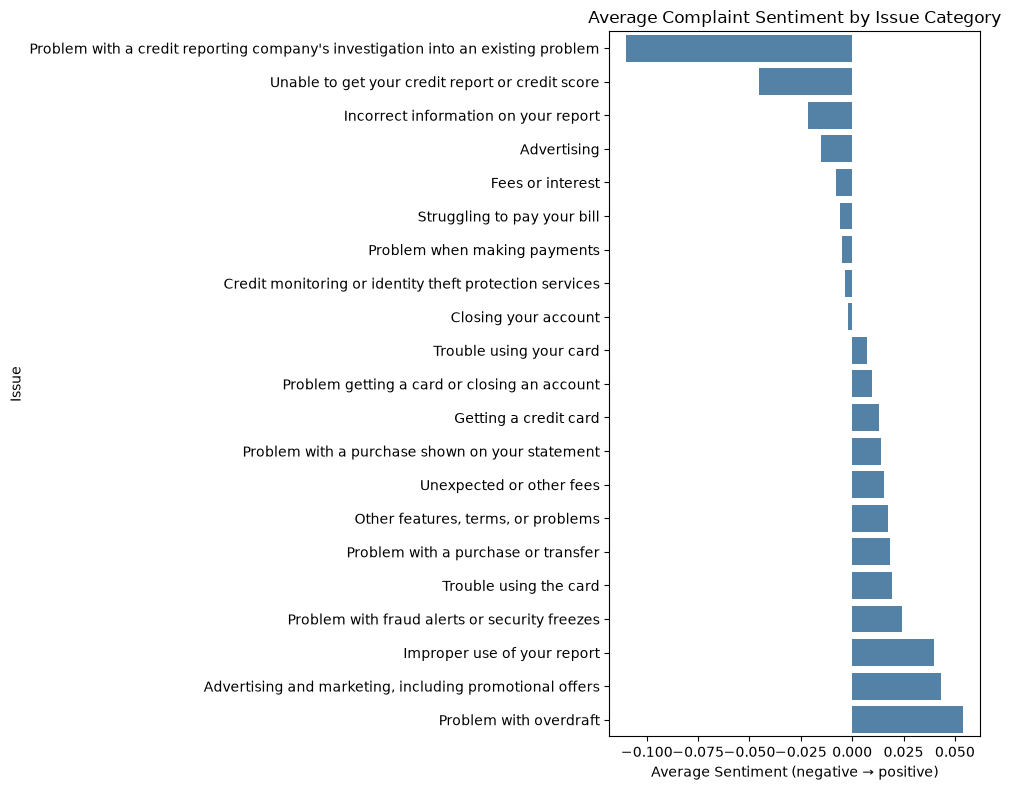

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Average sentiment per issue category, sorted from most negative to least
sentiment_by_issue = df.groupby('Issue')['sentiment'].mean().sort_values()

plt.figure(figsize=(10, 8))
sns.barplot(x=sentiment_by_issue.values, y=sentiment_by_issue.index, color='steelblue')
plt.xlabel('Average Sentiment (negative → positive)')
plt.title('Average Complaint Sentiment by Issue Category')
plt.tight_layout()
plt.show()

## 7. Hypothesis Test — Does Sentiment Really Differ by Issue Category?
H0: Average sentiment is the same across issue categories.
H1: Average sentiment differs significantly across issue categories.

We use a one-way ANOVA — it compares the average of a numeric variable (sentiment)
across multiple groups (issue categories) and tells us if at least one group is
meaningfully different from the rest.

In [19]:
from scipy import stats

# Group sentiment scores by issue category
groups = [group['sentiment'].values for name, group in df.groupby('Issue')]

# One-way ANOVA test
f_stat, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("Result: Statistically significant difference in sentiment across issue categories.")
else:
    print("Result: No statistically significant difference found.")

F-statistic: 112.75
P-value: 0.00000
Result: Statistically significant difference in sentiment across issue categories.


## 8. Does Sentiment Relate to How the Company Resolves the Complaint?
Checking whether more negative complaints are less likely to get a favorable resolution
(e.g. monetary relief) — this connects sentiment to a real business outcome, not just a
standalone score.

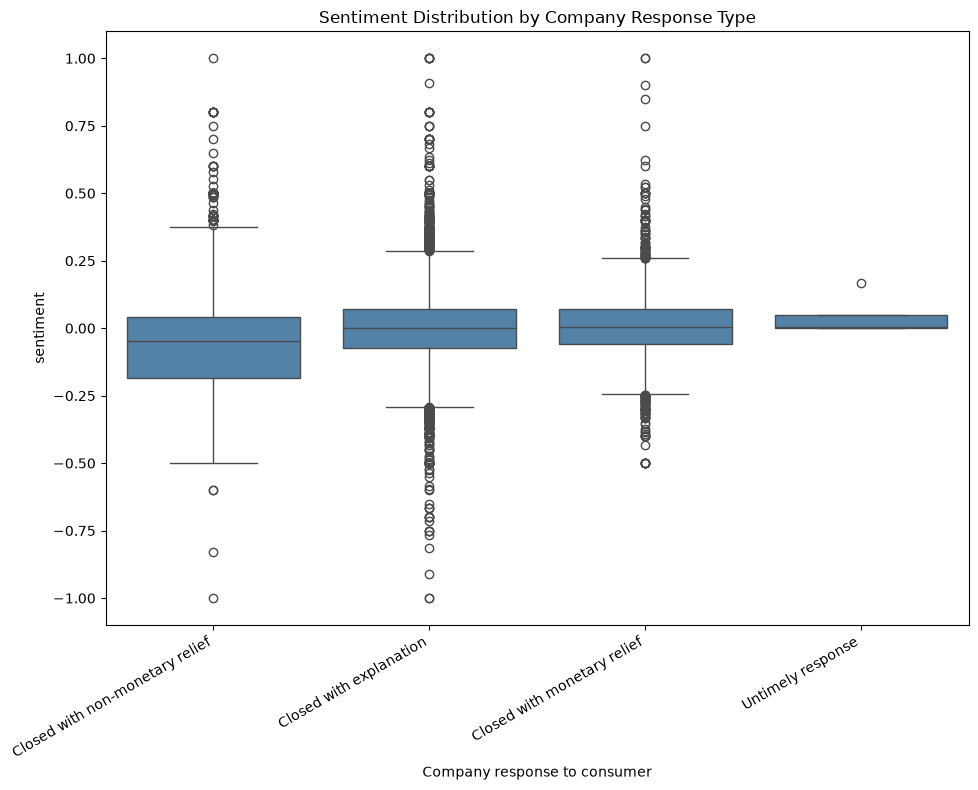

In [33]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, x='Company response to consumer', y='sentiment', color='steelblue')
plt.xticks(rotation=30, ha='right')
plt.title('Sentiment Distribution by Company Response Type')
plt.tight_layout()
plt.show()

In [23]:
groups2 = [group['sentiment'].values for name, group in df.groupby('Company response to consumer')]

f_stat2, p_value2 = stats.f_oneway(*groups2)

print(f"F-statistic: {f_stat2:.2f}")
print(f"P-value: {p_value2:.5f}")

if p_value2 < 0.05:
    print("Result: Statistically significant difference in sentiment across response types.")
else:
    print("Result: No statistically significant difference found.")
    

F-statistic: 114.05
P-value: 0.00000
Result: Statistically significant difference in sentiment across response types.


In [24]:
df.groupby('Company response to consumer')['sentiment'].agg(['mean', 'count'])


,mean,count
Company response to consumer,,
Closed with explanation,-0.004134,13622
Closed with monetary relief,0.006761,3534
Closed with non-monetary relief,-0.049434,4123
Untimely response,0.044524,4


## Finding: Sentiment vs. Resolution Type
While ANOVA shows a statistically significant difference (p<0.001) in sentiment across
company response types, the actual differences in mean sentiment are very small (all within
±0.05 on a -1 to +1 scale). With 21K+ complaints, even negligible differences can appear
"significant" — so this is not treated as a strong effect.

**Interpretation:** Company resolution type does not track meaningfully with how negative
the customer's language is. This suggests resolution decisions are likely driven by complaint
category/policy rather than the customer's expressed distress — a possible CX gap: sentiment
signals aren't being used to triage or escalate.

Note: "Untimely response" excluded from interpretation (only 4 complaints, not a reliable sample).

## 9. What's Actually Driving the Worst Sentiment? — Word Frequency
Looking at the most common words in the lowest-sentiment issue category to understand
*why* customers are most upset there, before summarizing with GenAI.

In [25]:
from collections import Counter
import re

# Isolate the worst-performing issue category from our earlier chart
worst_issue = "Problem with a credit reporting company's investigation into an existing problem"
subset = df[df['Issue'] == worst_issue]

# Simple word frequency count (lowercase, strip punctuation, drop short/common words)
stopwords = {'the','and','to','a','of','i','my','was','is','in','for','that','this',
             'it','on','with','have','be','not','they','me','as','are','their','been',
             'or','but','an','from','at','had','has','were','which','so','then'}

def get_words(text):
    words = re.findall(r'\b[a-z]{3,}\b', text.lower())
    return [w for w in words if w not in stopwords]

all_words = subset['narrative_clean'].apply(get_words).sum()
word_freq = Counter(all_words).most_common(20)

for word, count in word_freq:
    print(f"{word}: {count}")

account: 4415
late: 4337
never: 2115
payment: 2057
see: 1595
want: 1589
documents: 1547
attached: 1542
update: 1499
you: 1208
accounts: 1183
payments: 1146
time: 1084
these: 1042
always: 957
paid: 938
remove: 916
bureau: 916
investigation: 909
start: 885


## Finding: Root Cause of Worst-Sentiment Category
Word frequency analysis shows this category is dominated by late-payment reporting disputes —
customers submitting documentation ("documents attached") to prove a payment was not late,
requesting removal from their report after a bureau investigation. High frequency of "never,"
"want," "remove" suggests unresolved or unsatisfactory outcomes are common.

## 10. GenAI Summarization
Using an LLM to read a sample of narratives from the worst-sentiment category and generate
a short, readable summary — since manually reading thousands of complaints isn't feasible,
this mirrors how the JD describes applying GenAI to unstructured customer data.

In [26]:
sample_narratives = subset['narrative_clean'].sample(10, random_state=42).tolist()
for i, n in enumerate(sample_narratives, 1):
    print(f"{i}. {n}\n")

1. See the attached documents. I want the bureau to start the investigation on these accounts that I am never late for but they're reporting me as late.

2. It is truly absurd to witness late payments reflected on my account, as I have consistently paid this account on time without any instances of being late.

3. I want this late payment remove from my account, and I never been late with this account I working so hard to pay this monthly and this is not acceptable. See the documents attached.

4. See the attached documents. I want the bureau to start the investigation on these accounts that I am never late for but they're reporting me as late

5. See the attached documents. I want the bureau to start the investigation on these accounts. I am never been late on this account.

6. See the attached documents. I want the bureau to start the investigation on these accounts. I am never been late on this account.

7. I want this late payment remove from my account, and I never been late with 

## GenAI Summary — Late Payment Dispute Theme
Using an LLM to summarize a sample of 10 narratives from the worst-sentiment category
("Problem with a credit reporting company's investigation into an existing problem"):

- **Core dispute:** Nearly all complaints report a late payment mark the customer insists
  is inaccurate — they claim to have always paid on time.
- **Consistent action requested:** Customers want the bureau/company to investigate and
  remove the late payment entry from their credit report.
- **Evidence submitted:** Most complaints reference "attached documents" as proof of
  on-time payment, showing customers proactively submitting evidence.
- **Notable pattern:** Several narratives are near-identical in wording, suggesting many
  may be filed via template-based dispute letters (possibly credit repair services) rather
  than fully original complaints — worth noting as a caveat, though the underlying issue
  (disputed late payment marks) is still real and recurring.

In [27]:
df.to_csv('cc_complaints_clean.csv', index=False)
print("Exported:", df.shape)

Exported: (21283, 12)


## Finding: Geographic Concentration
28% of "credit reporting investigation" complaints originate from Illinois alone —
far higher than population share would predict. Worth flagging as a possible
company-specific or regional servicing pattern requiring further investigation
(e.g. checking if one company dominates IL complaints).

## Finding: American Express-Specific Breakdown
Filtering to Amex complaints only (1,163 total) shows a different pattern than the
overall dataset: their "credit reporting investigation" complaints (n=11) run near-neutral
sentiment, unlike the market-wide trend where this category is the worst performer.
Amex's most reliable negative signal, by volume, is "Fees or interest" (n=148, avg -0.0141).
Categories with fewer than ~20 complaints are excluded from interpretation due to
small sample size.